<a href="https://colab.research.google.com/github/Gangamma-yn/AI-Smart-Attendance-System/blob/main/day08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install diffusers transformers accelerate

Using device: cuda
Epoch 1/5, Average Loss = 0.4041
Epoch 2/5, Average Loss = 0.1345
Epoch 3/5, Average Loss = 0.1045
Epoch 4/5, Average Loss = 0.0810
Epoch 5/5, Average Loss = 0.0731
Training completed.


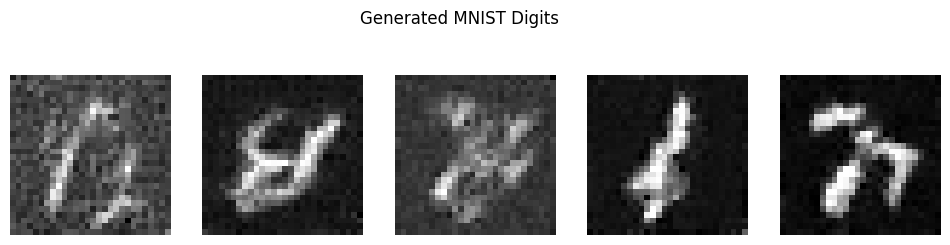

In [ ]:

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from diffusers import UNet2DModel, DDPMScheduler
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", device)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

dataset = Subset(dataset, range(5000))

train_loader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)

model = UNet2DModel(
    sample_size=28,
    in_channels=1,
    out_channels=1,
    layers_per_block=2,
    block_out_channels=(32, 64, 128),
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "DownBlock2D"
    ),
    up_block_types=(
        "UpBlock2D",
        "UpBlock2D",
        "UpBlock2D"
    )
).to(device)

noise_scheduler = DDPMScheduler(
    num_train_timesteps=1000
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

epochs = 5

for epoch in range(epochs):

    total_loss = 0

    for images, _ in train_loader:

        images = images.to(device)

        noise = torch.randn_like(images)

        timesteps = torch.randint(
            0,
            noise_scheduler.config.num_train_timesteps,
            (images.shape[0],),
            device=device
        ).long()

        noisy_images = noise_scheduler.add_noise(
            images,
            noise,
            timesteps
        )

        noise_pred = model(
            noisy_images,
            timesteps
        ).sample

        loss = F.mse_loss(noise_pred, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch+1}/{epochs}, Average Loss = {avg_loss:.4f}")

torch.save(model.state_dict(), "mnist_diffusion_model.pth")

print("Training completed.")

model.eval()

fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i in range(5):

    sample = torch.randn((1, 1, 28, 28)).to(device)

    for t in reversed(range(noise_scheduler.config.num_train_timesteps)):

        with torch.no_grad():

            timestep = torch.tensor([t], device=device)

            noise_pred = model(sample, timestep).sample

            sample = noise_scheduler.step(
                noise_pred,
                timestep,
                sample
            ).prev_sample

    image = sample.cpu().squeeze().numpy()

    axes[i].imshow(image, cmap="gray")
    axes[i].axis("off")

plt.suptitle("Generated MNIST Digits")
plt.show()


In [ ]:
#GAN

import torch
import torch.nn as nn
class DCGANGenerator(nn.Module):
    def __init__(self, z_dim=100, img_channels=3, features=64):
        super(DCGANGenerator, self).__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(z_dim, features * 8, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(features * 8),   # Normalise to stabilise training
            nn.ReLU(True),                  # ReLU: output = max(0, x)

            nn.ConvTranspose2d(features * 8, features * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(features * 4, features * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(features * 2, features, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features),
            nn.ReLU(True),

            nn.ConvTranspose2d(features, img_channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()   # Tanh squeezes values to [-1, 1] — matches our normalised images
        )
    def forward(self, z):
        # z shape: (batch_size, 100, 1, 1)
        return self.model(z)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")   # Should print: Running on: cuda  (on H200)
G = DCGANGenerator().to(device)
# Create a batch of 4 noise vectors  (4 images, each from 100 random numbers)
noise = torch.randn(4, 100, 1, 1).to(device)
fake_images = G(noise)
print(f"Input  (noise) shape : {noise.shape}")        # torch.Size([4, 100, 1, 1])
print(f"Output (images) shape: {fake_images.shape}")  # torch.Size([4, 3, 64, 64])
print(f"Pixel value range    : [{fake_images.min():.2f}, {fake_images.max():.2f}]")




# ─────────────────────────────────────────────────────────────────────────────
# DCGAN DISCRIMINATOR
# ─────────────────────────────────────────────────────────────────────────────
# What does the Discriminator do?
#   - It takes an image (64x64 RGB) as input — could be real OR fake
#   - It passes it through several Convolutional layers (DOWNSAMPLING, shrinking)
#   - It outputs a SINGLE NUMBER between 0 and 1:
#       1.0 = "I'm very sure this is REAL"
#       0.0 = "I'm very sure this is FAKE"
#       0.5 = "I have no idea!"
#
# The architecture is basically the REVERSE of the Generator.

class DCGANDiscriminator(nn.Module):
    def __init__(self, img_channels=3, features=64):
        super(DCGANDiscriminator, self).__init__()

        self.model = nn.Sequential(

            # ── LAYER 1 ────────────────────────────────────────────────────
            # Input: (batch, 3, 64, 64)  ← a 64x64 RGB image
            # stride=2 downsamples:  64x64 --> 32x32
            # NO BatchNorm in the very first layer (DCGAN paper rule)
            nn.Conv2d(img_channels, features, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # LeakyReLU(0.2): output = x if x>0, else 0.2*x
            # This prevents "dying" neurons (unlike ReLU which kills negatives completely)
            # Output shape: (batch, 64, 32, 32)

            # ── LAYER 2 ────────────────────────────────────────────────────
            # 32x32 --> 16x16
            nn.Conv2d(features, features * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # Output shape: (batch, 128, 16, 16)

            # ── LAYER 3 ────────────────────────────────────────────────────
            # 16x16 --> 8x8
            nn.Conv2d(features * 2, features * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # Output shape: (batch, 256, 8, 8)

            # ── LAYER 4 ────────────────────────────────────────────────────
            # 8x8 --> 4x4
            nn.Conv2d(features * 4, features * 8, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # Output shape: (batch, 512, 4, 4)

            # ── FINAL LAYER ────────────────────────────────────────────────
            # 4x4 --> 1x1  (a single number per image)
            nn.Conv2d(features * 8, 1, kernel_size=4, stride=1, padding=0, bias=False),
            nn.Sigmoid()   # Sigmoid squeezes output to [0, 1] = probability
            # Output shape: (batch, 1, 1, 1)
        )

    def forward(self, x):
        output = self.model(x)
        return output.view(-1)   # Flatten: (batch, 1, 1, 1) --> (batch,)
                                 # Now each image has ONE score


# ─────────────────────────────────────────────────────────────────────────────
# TEST THE DISCRIMINATOR
# ─────────────────────────────────────────────────────────────────────────────
D = DCGANDiscriminator().to(device)

# Give it the fake images from our Generator test
scores = D(fake_images.detach())   # .detach() stops gradients (just testing, not training)

print(f"Discriminator scores shape: {scores.shape}")       # torch.Size([4])
print(f"Discriminator scores      : {scores.tolist()}")
# e.g., [0.52, 0.49, 0.51, 0.48]
# These are near 0.5 — untrained Discriminator is just guessing randomly
# After training, it will score real images near 1.0 and fakes near 0.0


import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torchvision.utils as vutils

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1: HYPERPARAMETERS
# ─────────────────────────────────────────────────────────────────────────────
Z_DIM      = 100    # Size of the noise vector (input to Generator)
BATCH_SIZE = 64     # Number of images processed per step
LR         = 0.0002 # Learning rate — from the original DCGAN paper
BETA1      = 0.5    # Adam optimizer beta1 — lower than default (0.9) for GAN stability
NUM_EPOCHS = 25     # Number of full passes through the dataset

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2: LOAD THE DATASET
# ─────────────────────────────────────────────────────────────────────────────
# We normalise images to [-1, 1] to match the Generator's Tanh output range
transform = transforms.Compose([
    transforms.Resize(64),        # Resize all images to 64x64
    transforms.CenterCrop(64),    # Crop to exactly 64x64 (removes edges)
    transforms.ToTensor(),        # Convert PIL Image to PyTorch tensor [0,1]
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],     # Subtract 0.5 from each channel
        std =[0.5, 0.5, 0.5]      # Divide by 0.5 → values now in [-1, 1]
    )
])

# Using CelebA dataset (200k celebrity face images — standard GAN benchmark)
# You can replace this with any image folder using datasets.ImageFolder
# dataset = datasets.CelebA(root='./data', split='train', transform=transform, download=True)
# Changed to CIFAR10 due to FileURLRetrievalError with CelebA
dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

print(f"Total training images : {len(dataset)}")
print(f"Batches per epoch     : {len(loader)}")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 3: INITIALISE MODELS
# ─────────────────────────────────────────────────────────────────────────────
G = DCGANGenerator().to(device)
D = DCGANDiscriminator().to(device)

# Weight initialisation: DCGAN paper says initialise weights from
# Normal distribution with mean=0, std=0.02 (not the default PyTorch init)
def weights_init(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:           # Applies to Conv2d and ConvTranspose2d
        nn.init.normal_(m.weight.data, mean=0.0, std=0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, mean=1.0, std=0.02)  # BN weights ~ 1
        nn.init.constant_(m.bias.data, val=0)                # BN biases  = 0

G.apply(weights_init)   # Apply to all layers of Generator
D.apply(weights_init)   # Apply to all layers of Discriminator
print("Weights initialised.")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 4: LOSS FUNCTION AND OPTIMISERS
# ─────────────────────────────────────────────────────────────────────────────
# Binary Cross Entropy Loss — standard for binary classification (real vs fake)
criterion = nn.BCELoss()

# Separate optimisers for G and D — important! They update independently
# Adam with beta1=0.5 (standard DCGAN setting for stability)
opt_G = optim.Adam(G.parameters(), lr=LR, betas=(BETA1, 0.999))
opt_D = optim.Adam(D.parameters(), lr=LR, betas=(BETA1, 0.999))

# Fixed noise: we use the SAME noise every few epochs to visualise progress
fixed_noise = torch.randn(64, Z_DIM, 1, 1).to(device)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 5: THE TRAINING LOOP
# ─────────────────────────────────────────────────────────────────────────────
for epoch in range(NUM_EPOCHS):
    for step, (real_imgs, _) in enumerate(loader):
        real_imgs  = real_imgs.to(device)
        batch_size = real_imgs.size(0)   # May differ from BATCH_SIZE for last batch

        # Labels: 1.0 = real, 0.0 = fake
        # Label smoothing: use 0.9 instead of 1.0 for real labels
        # Why? This prevents D from becoming overconfident, which destabilises G
        real_labels = torch.full((batch_size,), 0.9, device=device)  # 0.9 not 1.0
        fake_labels = torch.zeros(batch_size, device=device)          # 0.0

        # ══════════════════════════════════════════════════════════════════
        # TRAIN DISCRIMINATOR
        # Goal: D should output high scores for real, low for fake
        # ══════════════════════════════════════════════════════════════════
        opt_D.zero_grad()   # Clear previous gradients (ALWAYS do this first!)

        # -- Part A: Loss on REAL images --
        # Feed real images, compare D's output to real_labels (0.9)
        pred_real  = D(real_imgs)
        loss_D_real = criterion(pred_real, real_labels)
        # If D correctly scores real images near 0.9, this loss is LOW (good)
        # If D scores real images near 0.0, this loss is HIGH (D made mistake)

        # -- Part B: Loss on FAKE images --
        noise     = torch.randn(batch_size, Z_DIM, 1, 1).to(device)
        fake_imgs = G(noise).detach()
        # IMPORTANT: .detach() stops gradients from flowing back through G
        # We are only training D right now — we don't want G to update here

        pred_fake  = D(fake_imgs)
        loss_D_fake = criterion(pred_fake, fake_labels)
        # If D correctly scores fake images near 0.0, this loss is LOW (good)

        # -- Total D loss and update --
        loss_D = (loss_D_real + loss_D_fake) / 2   # Average of both losses
        loss_D.backward()   # Compute gradients
        opt_D.step()        # Update D's weights

        # ══════════════════════════════════════════════════════════════════
        # TRAIN GENERATOR
        # Goal: G should make images that D scores HIGH (thinks they are real)
        # ══════════════════════════════════════════════════════════════════
        opt_G.zero_grad()   # Clear previous gradients

        noise     = torch.randn(batch_size, Z_DIM, 1, 1).to(device)
        fake_imgs = G(noise)   # No .detach() this time — we WANT gradients to flow to G

        pred_fake = D(fake_imgs)
        # TRICK: We use real_labels (0.9) for G's loss
        # G WANTS D to output 0.9 (think fakes are real)
        # If D says 0.1, G was bad — high loss, big gradient update
        # If D says 0.9, G was good — low loss, small update
        loss_G = criterion(pred_fake, real_labels)

        loss_G.backward()   # Compute gradients for G
        opt_G.step()        # Update G's weights (D's weights are NOT changed here)

        # ── Log every 100 steps ───────────────────────────────────────────
        if step % 100 == 0:
            print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS}] "
                  f"Step [{step:4d}/{len(loader)}] "
                  f"Loss_D: {loss_D.item():.4f}  "
                  f"Loss_G: {loss_G.item():.4f}  "
                  f"D(real): {pred_real.mean().item():.3f}  "
                  f"D(fake): {pred_fake.mean().item():.3f}")

    # ── Save generated images at end of each epoch ────────────────────────
    with torch.no_grad():
        fake_samples = G(fixed_noise).detach().cpu()
    vutils.save_image(fake_samples, f"gan_epoch_{epoch+1}.png",
                      normalize=True, nrow=8)
    print(f"  --> Saved sample image: gan_epoch_{epoch+1}.png")

# ─────────────────────────────────────────────────────────────────────────────
# WHAT TO EXPECT DURING TRAINING
# ─────────────────────────────────────────────────────────────────────────────
# Epoch  1 : Images look like coloured blobs / noise (normal!)
# Epoch  5 : Face-like shapes begin to appear (rough outlines)
# Epoch 15 : Recognisable faces with some distortion
# Epoch 25 : Sharp faces that look somewhat realistic
#
# Healthy loss range:
#   Loss_D should hover around 0.4 - 0.7 (D is uncertain, as expected)
#   Loss_G should hover around 0.5 - 1.5 (G is improving)
#   If Loss_D --> 0: Discriminator is too powerful (mode collapse risk)
#   If Loss_G --> 0: Generator has completely fooled D

Running on: cuda
Input  (noise) shape : torch.Size([4, 100, 1, 1])
Output (images) shape: torch.Size([4, 3, 64, 64])
Pixel value range    : [-1.00, 1.00]
Discriminator scores shape: torch.Size([4])
Discriminator scores      : [0.5844570398330688, 0.5147178173065186, 0.5358244180679321, 0.5355627536773682]


100%|██████████| 170M/170M [03:12<00:00, 884kB/s]


Total training images : 50000
Batches per epoch     : 782
Weights initialised.
Epoch [ 1/25] Step [   0/782] Loss_D: 0.9892  Loss_G: 5.3147  D(real): 0.593  D(fake): 0.007
Epoch [ 1/25] Step [ 100/782] Loss_D: 0.3353  Loss_G: 5.7360  D(real): 0.777  D(fake): 0.003
Epoch [ 1/25] Step [ 200/782] Loss_D: 0.2662  Loss_G: 2.3934  D(real): 0.706  D(fake): 0.084
Epoch [ 1/25] Step [ 300/782] Loss_D: 0.3346  Loss_G: 3.2704  D(real): 0.616  D(fake): 0.034
Epoch [ 1/25] Step [ 400/782] Loss_D: 0.6161  Loss_G: 3.4182  D(real): 0.791  D(fake): 0.073
Epoch [ 1/25] Step [ 500/782] Loss_D: 0.4819  Loss_G: 4.6960  D(real): 0.904  D(fake): 0.007
Epoch [ 1/25] Step [ 600/782] Loss_D: 0.2433  Loss_G: 4.0240  D(real): 0.850  D(fake): 0.022
Epoch [ 1/25] Step [ 700/782] Loss_D: 0.5292  Loss_G: 5.7455  D(real): 0.972  D(fake): 0.003
  --> Saved sample image: gan_epoch_1.png
Epoch [ 2/25] Step [   0/782] Loss_D: 0.3277  Loss_G: 3.9312  D(real): 0.919  D(fake): 0.025
Epoch [ 2/25] Step [ 100/782] Loss_D: 0.29

/usr/local/lib/python3.12/dist-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_safe_repr.py:128: FutureWarning: Accessing config attribute `__iter__` directly via 'UNet2DModel' object attribute is deprecated. Please access '__iter__' over 'UNet2DModel's config object instead, e.g. 'unet.config.__iter__'.
  if not hasattr(obj, "__iter__"):


Epoch [ 3/25] Step [ 300/782] Loss_D: 0.2387  Loss_G: 3.6274  D(real): 0.886  D(fake): 0.024


/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:173: FutureWarning: Accessing config attribute `__iter__` directly via 'DDPMScheduler' object attribute is deprecated. Please access '__iter__' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.__iter__'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


Epoch [ 3/25] Step [ 400/782] Loss_D: 0.3945  Loss_G: 3.3470  D(real): 0.898  D(fake): 0.034
Epoch [ 3/25] Step [ 500/782] Loss_D: 0.3966  Loss_G: 3.0454  D(real): 0.870  D(fake): 0.048
Epoch [ 3/25] Step [ 600/782] Loss_D: 0.6021  Loss_G: 3.9750  D(real): 0.905  D(fake): 0.020
Epoch [ 3/25] Step [ 700/782] Loss_D: 0.8232  Loss_G: 0.8888  D(real): 0.236  D(fake): 0.478
  --> Saved sample image: gan_epoch_3.png
Epoch [ 4/25] Step [   0/782] Loss_D: 0.3208  Loss_G: 2.3634  D(real): 0.685  D(fake): 0.091
Epoch [ 4/25] Step [ 100/782] Loss_D: 0.4911  Loss_G: 1.7852  D(real): 0.584  D(fake): 0.182
Epoch [ 4/25] Step [ 200/782] Loss_D: 0.3383  Loss_G: 4.1986  D(real): 0.817  D(fake): 0.015
Epoch [ 4/25] Step [ 300/782] Loss_D: 0.4958  Loss_G: 2.2831  D(real): 0.474  D(fake): 0.127
Epoch [ 4/25] Step [ 400/782] Loss_D: 0.4081  Loss_G: 2.1875  D(real): 0.629  D(fake): 0.119
Epoch [ 4/25] Step [ 500/782] Loss_D: 0.8103  Loss_G: 3.5322  D(real): 0.912  D(fake): 0.031
Epoch [ 4/25] Step [ 600/782